## Project Backlog
### 1. Project Setup
* Choose the dataset

* Define research questions

* Create GitHub repository

* Assign responsibilities


### 2. Data Cleaning
* Load dataset

* Check missing values

* Remove duplicates

* Convert data types

* Export cleaned dataset

### 3. Univariate EDA
* Summary statistics

* Histograms

* Boxplots

* Bar charts

* Conclusions

### 4. Bivariate EDA
* GroupBy

* Crosstab

* Scatterplots

* Correlation

* Conclusions

### 5. SQL
* Import dataset

* Create table

* Write queries

* Save queries

### 6. Documentation
* README

* Notebook comments

* Conclusions

### 7. Presentation
* Slides

* Assign speakers

* Practice

### 8. Final Review
* Merge branches

* Final checks

* Submit

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [103]:
df = pd.read_csv("dataset/football_matches_dataset.csv")


In [104]:
df.head()

,Unnamed: 0,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,...,home_defense_rating_last_2_home_matches,away_defense_rating_last_2_away_matches,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches
0,0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [105]:
df.shape

(16332, 55)

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16332 entries, 0 to 16331
Data columns (total 55 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Unnamed: 0                                16332 non-null  int64  
 1   home_team                                 16332 non-null  object 
 2   away_team                                 16332 non-null  object 
 3   date                                      16332 non-null  object 
 4   league                                    16332 non-null  object 
 5   season                                    16332 non-null  object 
 6   home_score                                16332 non-null  int64  
 7   away_score                                16332 non-null  int64  
 8   home_xg                                   16332 non-null  float64
 9   away_xg                                   16332 non-null  float64
 10  datetime                          

In [107]:
list(df.columns)

['Unnamed: 0',
 'home_team',
 'away_team',
 'date',
 'league',
 'season',
 'home_score',
 'away_score',
 'home_xg',
 'away_xg',
 'datetime',
 'home_standings',
 'away_standings',
 'home_points',
 'away_points',
 'home_points_last_4_matches',
 'away_points_last_4_matches',
 'home_points_last_2_home_matches',
 'away_points_last_2_away_matches',
 'home_goals_last_4_matches',
 'away_goals_last_4_matches',
 'home_goals_last_2_home_matches',
 'away_goals_last_2_away_matches',
 'home_goals_against_last_4_matches',
 'away_goals_against_last_4_matches',
 'home_goals_against_last_2_home_matches',
 'away_goals_against_last_2_away_matches',
 'home_mean_xg_last_4_matches',
 'away_mean_xg_last_4_matches',
 'home_mean_xg_last_2_home_matches',
 'away_mean_xg_last_2_away_matches',
 'home_mean_xg_against_last_4_matches',
 'away_mean_xg_against_last_4_matches',
 'home_mean_xg_against_last_2_home_matches',
 'away_mean_xg_against_last_2_away_matches',
 'home_formation',
 'away_formation',
 'home_defense_ra

MISSING Values

In [108]:
df.isnull().sum()

Unnamed: 0                                    0
home_team                                     0
away_team                                     0
date                                          0
league                                        0
season                                        0
home_score                                    0
away_score                                    0
home_xg                                       0
away_xg                                       0
datetime                                      0
home_standings                                0
away_standings                                0
home_points                                   0
away_points                                   0
home_points_last_4_matches                  312
away_points_last_4_matches                  316
home_points_last_2_home_matches             314
away_points_last_2_away_matches             314
home_goals_last_4_matches                   312
away_goals_last_4_matches               

In [109]:
missing = df.isnull().sum()     #check

missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage.round(2)
}).sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
away_points_last_4_matches,316,1.93
away_attack_rating_last_4_matches,316,1.93
away_goals_against_last_4_matches,316,1.93
away_midfield_rating_last_4_matches,316,1.93
away_goals_last_4_matches,316,1.93
away_defense_rating_last_4_matches,316,1.93
away_mean_xg_last_4_matches,316,1.93
away_mean_xg_against_last_4_matches,316,1.93
away_attack_rating_last_2_away_matches,314,1.92
away_goals_against_last_2_away_matches,314,1.92


In [110]:
clean_df = df.drop(columns=["Unnamed: 0"])

In [111]:
clean_df["datetime"] = pd.to_datetime(clean_df["datetime"])

In [112]:
# Create total_goals
clean_df["total_goals"] = clean_df["home_score"] + clean_df["away_score"]

# Create total_xg
clean_df["total_xg"] = clean_df["home_xg"] + clean_df["away_xg"]
print(clean_df.columns.tolist())

['home_team', 'away_team', 'date', 'league', 'season', 'home_score', 'away_score', 'home_xg', 'away_xg', 'datetime', 'home_standings', 'away_standings', 'home_points', 'away_points', 'home_points_last_4_matches', 'away_points_last_4_matches', 'home_points_last_2_home_matches', 'away_points_last_2_away_matches', 'home_goals_last_4_matches', 'away_goals_last_4_matches', 'home_goals_last_2_home_matches', 'away_goals_last_2_away_matches', 'home_goals_against_last_4_matches', 'away_goals_against_last_4_matches', 'home_goals_against_last_2_home_matches', 'away_goals_against_last_2_away_matches', 'home_mean_xg_last_4_matches', 'away_mean_xg_last_4_matches', 'home_mean_xg_last_2_home_matches', 'away_mean_xg_last_2_away_matches', 'home_mean_xg_against_last_4_matches', 'away_mean_xg_against_last_4_matches', 'home_mean_xg_against_last_2_home_matches', 'away_mean_xg_against_last_2_away_matches', 'home_formation', 'away_formation', 'home_defense_rating', 'away_defense_rating', 'home_midfield_rating

In [113]:
clean_df.head(100)

,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,datetime,...,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches,total_goals,total_xg
0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,2014-08-08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4.03
1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,2014-08-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,2.05
2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,2014-08-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2.13
3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,2014-08-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.60
4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,2014-08-09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Werder Bremen,Hoffenheim,August 30 2014,Bundesliga,2014/2015,1,1,2.51,1.30,2014-08-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.81
96,West Ham,Southampton,August 30 2014,EPL,2014/2015,1,3,0.64,1.58,2014-08-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2.22
97,Wolfsburg,Eintracht Frankfurt,August 30 2014,Bundesliga,2014/2015,2,2,1.00,1.60,2014-08-30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2.60
98,AC Milan,Lazio,August 31 2014,Serie A,2014/2015,3,1,2.01,2.04,2014-08-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4.05


1. RQ1. Is Expected Goals (xG) a good predictor of actual goals?**

In [114]:
import sqlite3
import pandas as pd

# Crea/conecta a una base de datos (se guarda como archivo .db en tu carpeta)
conn = sqlite3.connect("football.db")

# Vuelca clean_df como tabla SQL llamada "matches"
clean_df.to_sql("matches", conn, if_exists="replace", index=False)

16332

In [115]:
check = pd.read_sql_query("SELECT * FROM matches LIMIT 5", conn)
check

,home_team,away_team,date,league,season,home_score,away_score,home_xg,away_xg,datetime,...,home_midfield_rating_last_4_matches,away_midfield_rating_last_4_matches,home_midfield_rating_last_2_home_matches,away_midfield_rating_last_2_away_matches,home_attack_rating_last_4_matches,away_attack_rating_last_4_matches,home_attack_rating_last_2_home_matches,away_attack_rating_last_2_away_matches,total_goals,total_xg
0,Reims,Paris Saint Germain,August 08 2014,Ligue 1,2014/2015,2,2,1.37,2.66,2014-08-08 00:00:00,...,None,None,None,None,None,None,None,None,4,4.03
1,Evian Thonon Gaillard,Caen,August 09 2014,Ligue 1,2014/2015,0,3,0.81,1.24,2014-08-09 00:00:00,...,None,None,None,None,None,None,None,None,3,2.05
2,Guingamp,Saint-Etienne,August 09 2014,Ligue 1,2014/2015,0,2,0.63,1.50,2014-08-09 00:00:00,...,None,None,None,None,None,None,None,None,2,2.13
3,Lille,Metz,August 09 2014,Ligue 1,2014/2015,0,0,1.54,0.06,2014-08-09 00:00:00,...,None,None,None,None,None,None,None,None,0,1.60
4,Montpellier,Bordeaux,August 09 2014,Ligue 1,2014/2015,0,1,1.02,0.75,2014-08-09 00:00:00,...,None,None,None,None,None,None,None,None,1,1.77


Calculate average goals per league

In [116]:
query1 = """
SELECT league, AVG(total_goals) AS avg_goals
FROM matches
GROUP BY league
ORDER BY avg_goals DESC
"""
result1 = pd.read_sql_query(query1, conn)
result1

,league,avg_goals
0,Bundesliga,2.995280
1,Serie A,2.789181
2,EPL,2.739181
3,Ligue 1,2.649186
4,La liga,2.625146


Average of total xgoals per season

In [117]:
query2 = """
SELECT season, AVG(total_xg) AS avg_xg
FROM matches
GROUP BY season
ORDER BY season
"""
result2 = pd.read_sql_query(query2, conn)
result2

,season,avg_xg
0,2014/2015,2.545860
1,2015/2016,2.609272
2,2016/2017,2.625047
3,2017/2018,2.631002
4,2018/2019,2.809053
5,2019/2020,2.806800
6,2020/2021,2.745969
7,2021/2022,2.824847
8,2022/2023,2.866572


xG promedio vs goles reales promedio, por liga y temporada

In [118]:
query3 = """
SELECT league, season,
       AVG(total_xg) AS avg_xg,
       AVG(total_goals) AS avg_goals,
       AVG(total_goals) - AVG(total_xg) AS avg_diff
FROM matches
GROUP BY league, season
ORDER BY league, season
"""
result3 = pd.read_sql_query(query3, conn)
result3

,league,season,avg_xg,avg_goals,avg_diff
0,Bundesliga,2014/2015,2.624052,2.754902,0.130850
1,Bundesliga,2015/2016,2.824314,2.830065,0.005752
2,Bundesliga,2016/2017,2.754150,2.866013,0.111863
3,Bundesliga,2017/2018,2.672386,2.794118,0.121732
4,Bundesliga,2018/2019,3.184935,3.179739,-0.005196
5,Bundesliga,2019/2020,3.128431,3.209150,0.080719
6,Bundesliga,2020/2021,2.860654,3.032680,0.172026
7,Bundesliga,2021/2022,3.119412,3.117647,-0.001765
8,Bundesliga,2022/2023,3.026471,3.173203,0.146732
9,EPL,2014/2015,2.543789,2.565789,0.022000


In [119]:
correlation = clean_df["total_xg"].corr(clean_df["total_goals"])
print(f"Correlation between total_xg and total_goals: {correlation:.4f}")

Correlation between total_xg and total_goals: 0.5733


In [120]:
import numpy as np

# Create goal_difference
clean_df["goal_difference"] = clean_df["home_score"] - clean_df["away_score"]

# Create match_result
conditions = [
    clean_df["home_score"] > clean_df["away_score"],
    clean_df["home_score"] < clean_df["away_score"]
]
choices = ["Home Win", "Away Win"]
clean_df["match_result"] = np.select(conditions, choices, default="Draw")

In [121]:
print(clean_df.columns.tolist())

['home_team', 'away_team', 'date', 'league', 'season', 'home_score', 'away_score', 'home_xg', 'away_xg', 'datetime', 'home_standings', 'away_standings', 'home_points', 'away_points', 'home_points_last_4_matches', 'away_points_last_4_matches', 'home_points_last_2_home_matches', 'away_points_last_2_away_matches', 'home_goals_last_4_matches', 'away_goals_last_4_matches', 'home_goals_last_2_home_matches', 'away_goals_last_2_away_matches', 'home_goals_against_last_4_matches', 'away_goals_against_last_4_matches', 'home_goals_against_last_2_home_matches', 'away_goals_against_last_2_away_matches', 'home_mean_xg_last_4_matches', 'away_mean_xg_last_4_matches', 'home_mean_xg_last_2_home_matches', 'away_mean_xg_last_2_away_matches', 'home_mean_xg_against_last_4_matches', 'away_mean_xg_against_last_4_matches', 'home_mean_xg_against_last_2_home_matches', 'away_mean_xg_against_last_2_away_matches', 'home_formation', 'away_formation', 'home_defense_rating', 'away_defense_rating', 'home_midfield_rating

In [122]:
clean_df.to_sql("matches", conn, if_exists="replace", index=False)

16332

In [123]:
query4 = """
SELECT match_result, AVG(total_xg) AS avg_xg, COUNT(*) AS num_matches
FROM matches
GROUP BY match_result
"""
result4 = pd.read_sql_query(query4, conn)
result4

,match_result,avg_xg,num_matches
0,Away Win,2.799690,4975
1,Draw,2.415977,4087
2,Home Win,2.831274,7270


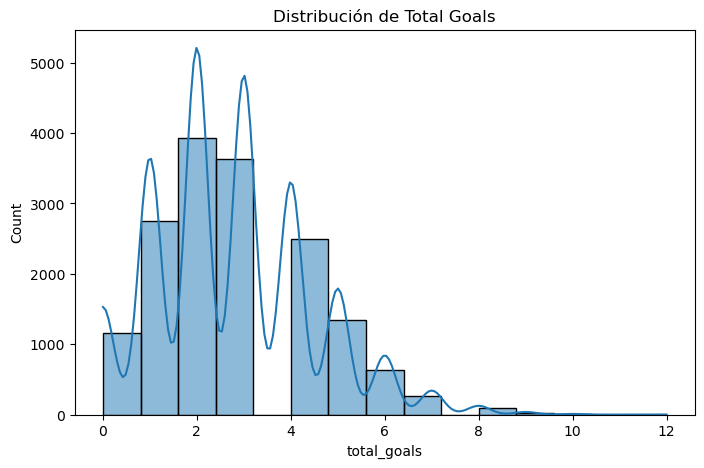

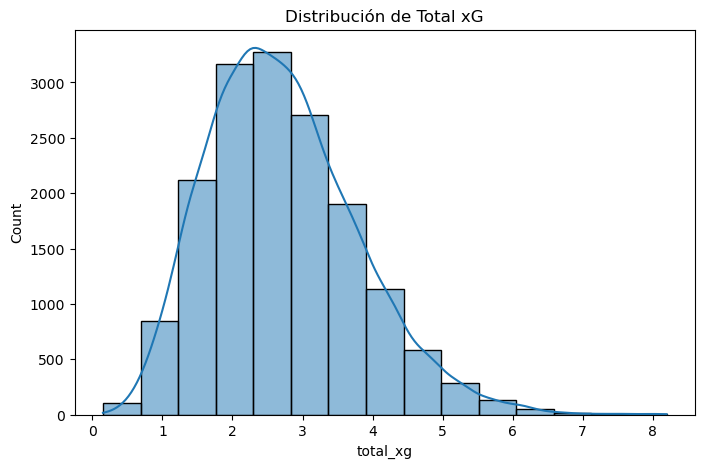

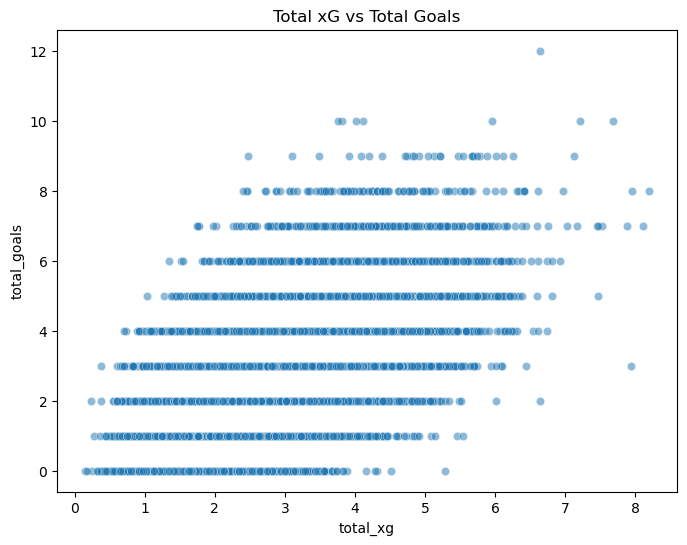

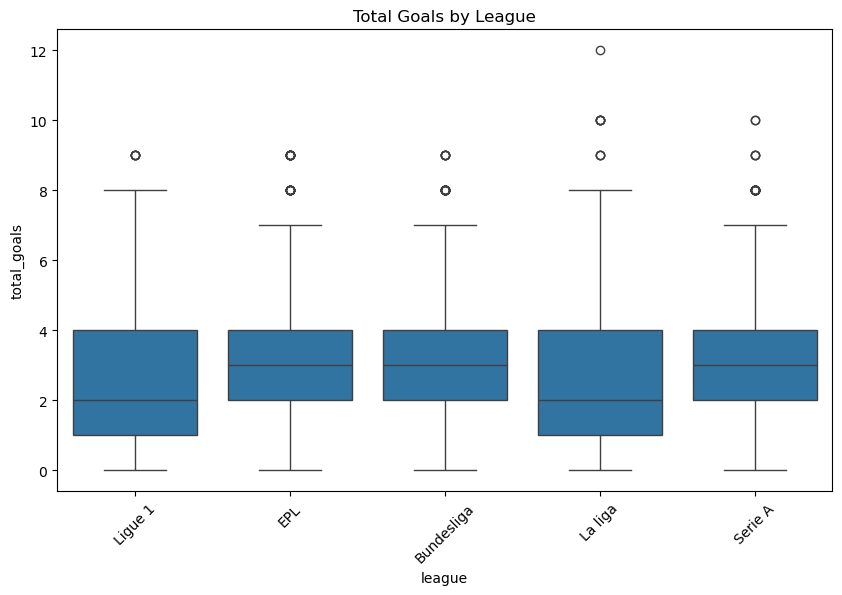

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma - distribución de total_goals
plt.figure(figsize=(8,5))
sns.histplot(clean_df["total_goals"], bins=15, kde=True)
plt.title("Distribución de Total Goals")
plt.show()

# Histograma - distribución de total_xg
plt.figure(figsize=(8,5))
sns.histplot(clean_df["total_xg"], bins=15, kde=True)
plt.title("Distribución de Total xG")
plt.show()

# Scatter plot: total_xg vs total_goals
plt.figure(figsize=(8,6))
sns.scatterplot(data=clean_df, x="total_xg", y="total_goals", alpha=0.5)
plt.title("Total xG vs Total Goals")
plt.show()

# Boxplot por liga
plt.figure(figsize=(10,6))
sns.boxplot(data=clean_df, x="league", y="total_goals")
plt.xticks(rotation=45)
plt.title("Total Goals by League")
plt.show()

In [125]:
# Create xg_difference
clean_df["xg_difference"] = clean_df["home_xg"] - clean_df["away_xg"]

In [98]:
clean_df.to_sql("matches", conn, if_exists="replace", index=False)

16332

In [99]:
correlation_diff = clean_df["xg_difference"].corr(clean_df["goal_difference"])
print(f"Correlation between xg_difference and goal_difference: {correlation_diff:.4f}")

Correlation between xg_difference and goal_difference: 0.6792


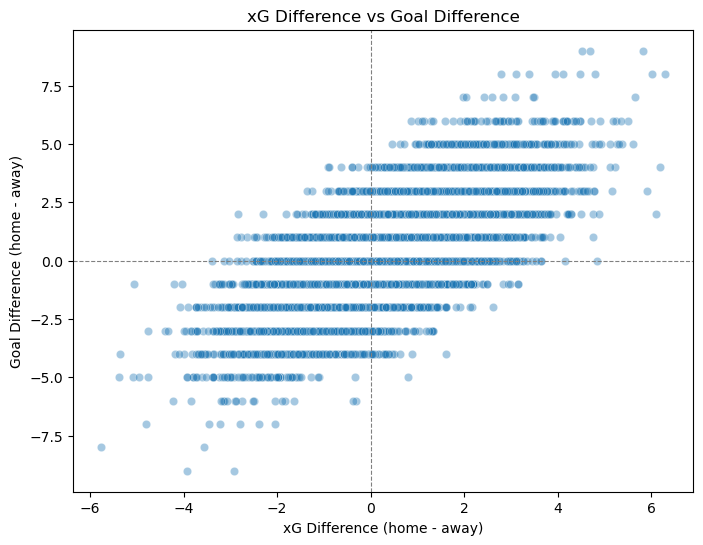

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=clean_df, x="xg_difference", y="goal_difference", alpha=0.4)
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.title("xG Difference vs Goal Difference")
plt.xlabel("xG Difference (home - away)")
plt.ylabel("Goal Difference (home - away)")
plt.show()

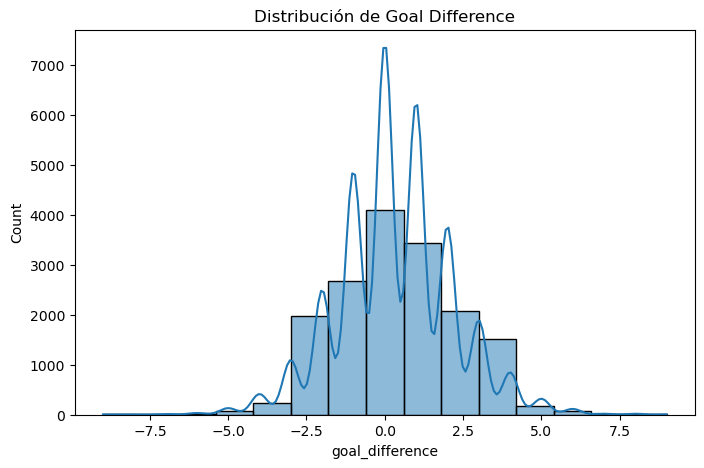

In [101]:
plt.figure(figsize=(8,5))
sns.histplot(clean_df["goal_difference"], bins=15, kde=True)
plt.title("Distribución de Goal Difference")
plt.show()

## RQ1: Is Expected Goals (xG) a good predictor of actual goals?

Expected Goals shows a moderate-to-strong relationship with actual goals scored. The correlation 
between `total_xg` and `total_goals` is **0.57**, meaning xG captures a good portion of scoring 
output, though finishing quality and luck still play a role match-to-match.

The relationship is even stronger when looking at match dominance: `xg_difference` and 
`goal_difference` correlate at **0.68**, suggesting that when a team creates significantly better 
chances than its opponent, that advantage is fairly likely to show up on the scoreboard.

**Conclusion:** xG is a reasonably good predictor of actual goals, particularly for identifying 
which team dominates a match — but it doesn't fully replace actual results, since finishing 
efficiency still introduces meaningful variance.